In [1]:
#! /usr/bin/env python3
import numpy as np
import sys
import h5py

In [2]:


sys.path.append("../python")  # Adjust the path to build/python/
sys.path.append(".")

## load the necessary modules
from canoe import def_species, load_configure, index_map
from canoe.snap import def_thermo
from canoe.athena import Mesh, ParameterInput, Outputs, MeshBlock
from canoe.harp import radiation_band, radiation

'''
    Overwrite the properties of a specific layer in the meshblock.

    Parameters:
    mb (MeshBlock): The meshblock containing the air column.
    ilayer (int): The index of the layer to overwrite.
    temp (float): K
    nh3_ppmv (float): The NH3 mixing ratio in ppmv to set for the layer.
    h2o_ppmv (float): The H2O mixing ratio in ppmv to set for the layer.
    electron (float): The electron density to set for the layer.
'''


def query_layer_properties(mb, ilayer):
    """
    Check if the layer has the required properties.
    If not, raise an error.
    """
    aircolumn = mb.get_aircolumn(mb.k_st, mb.j_st + Jindex, mb.i_st, mb.i_ed)  
    ap_mole = aircolumn[ilayer].to_mole_fraction()

    P = ap_mole.get_pressure()
    T = ap_mole.get_temp()
    theta = mb.get_theta(P0, mb.k_st, mb.j_st + Jindex, mb.i_st + ilayer)
    # print(f"  Θ = {theta:0.2f} K")
    xnh3=ap_mole.hydro()[iNH3] * 1E6
    xH2O = ap_mole.hydro()[iH2O] * 1E6
    
    elec=mb.get_tracer(ielec, mb.k_st, mb.j_st + Jindex, mb.i_st + ilayer) 
    # Na=mb.get_tracer(iNa, mb.k_st, mb.j_st + Jindex, mb.i_st + ilayer)  
    print(f"Layer {ilayer}: P={P:0.2f} Pa, T={T:0.2f} K, NH3={xnh3:0.2f} ppmv, H2O={xH2O:0.2f} ppmv, e-={elec:0.2E} m^-3")


def overwrite_layer_properties(mb, ilayer, temp, nh3_ppmv, h2o_ppmv, electron):

    aircolumn = mb.get_aircolumn(mb.k_st, mb.j_st + Jindex, mb.i_st, mb.i_ed)  
    ap_mole = aircolumn[ilayer].to_mole_fraction()

    # set temperature, NH3, H2O
    ap_mole.set_temp(temp)
    ap_mole.set_property(iNH3, nh3_ppmv/1E6)
    ap_mole.set_property(iH2O, h2o_ppmv/1E6)

    # put back to the air column
    mb.distribute_to_primitive(mb.k_st, mb.j_st + Jindex, mb.i_st + ilayer, ap_mole)

    # set electron
    mb.set_tracer(ielec, mb.k_st, mb.j_st + Jindex, mb.i_st + ilayer, electron)  
    # mb.set_tracer(iNa, mb.k_st, mb.j_st + Jindex, mb.i_st + ilayer, pNa)  



In [3]:
# set metallicity
metallicity= -2


In [4]:

## ========================================================================
##                       configure the Juno MWR forward model
##--------------------------------------------------------------------------
# load the configuration file
pin = ParameterInput()
pin.load_from_file("juno_mwr.inp")
pin.set_boolean("job", "verbose", False)  

# register the speicies and thermodynamics
vapors = pin.get_string("species", "vapor").split(", ")
clouds = pin.get_string("species", "cloud").split(", ")
tracers = pin.get_string("species", "tracer").split(", ")

def_species(vapors=vapors, clouds=clouds, tracers=tracers)
def_thermo(pin)

# load bands and opacities
config = load_configure("juno_mwr.yaml")


# set incident angles 
angle =[0.0, 15, 30.0, 45.]  # in degrees
angles = ' '.join([f"({x},)" for x in angle])
pin.set_string("radiation","outdir",angles)
print(pin.get_string("radiation","outdir"))


# set the gravity 
pin.set_string("hydro", "grav_acc1", f"{-23.3}") # Equatorial zone
# pin.set_string("hydro", "grav_acc1", f"{-27.01}") # pole 
print("Gravity acceleration:", pin.get_string("hydro", "grav_acc1"))


# set metallicity
pin.set_string("problem", "metallicity", f"{metallicity}")  # metallic
print("Metallicity:", pin.get_string("problem", "metallicity"))

# get index_map 
pindex = index_map.get_instance()
iNH3 = pindex.get_vapor_id("NH3")
iH2O = pindex.get_vapor_id("H2O")
ielec = pindex.get_tracer_id("e-")  # index for electron
iNa = pindex.get_tracer_id("Na")  # index for sodium

print(f"iNH3 = {iNH3}, iH2O = {iH2O}, ielec = {ielec}, iNa = {iNa}")

P0 = pin.get_real("mesh", "ReferencePressure")
print(f"Reference Pressure: {P0} Pa")


# set mesh; we use the 1st column of the 1st meshblock of the Athena++ mesh
nx2 = 1  # air column number, single column in this case
pin.set_string("mesh", "nx2", f"{nx2}")

# init the Mesh
mesh = Mesh(pin) 
mesh.initialize(pin)

global mb
# get the first meshblock
mb = mesh.meshblock(0)  


##=============================================================================================
##                  construct atmosphere: moist adiabate + constant NH3
##---------------------------------------------------------------------------------------------

# EZ abundances and temperature in Cheng (2020) 
xNH3=351     # deep-layer abundance, ppmv
xH2O=2500    # ppmv
T1bar=169    # 1-bar temperature, K

## use the first ap column of the block
Jindex=0   # Jindex ∈ [0, nx2-1]

## RH limit 
RHmax=1  # limit of relative humidity, 1 means 100%, only affects NH3 cloud-layer, set to 1 in EZ
maxint=200  # do not change

## a moist adiabatic uniform NH3 profile, with RHlimit
adiabate="pseudo"  # or "dry"

# construct the atmosphere
mb.construct_atmosphere(pin, xNH3, T1bar, RHmax, Jindex, adiabate, xH2O, maxint)

# ----------------------------  get the pressure grid  -----------------------------------------
aircolumn = mb.get_aircolumn(mb.k_st, mb.j_st + Jindex, mb.i_st, mb.i_ed)   
#### loop over layers bottom up
nlyr=len(aircolumn)  
pressure_model= np.array([0.0] * nlyr)  # pressure in Pa
NH3_org= np.array([0.0]*nlyr)   ## mole fraction, eg., 380 ppmv
H2O_org= np.array([0.0]*nlyr)   ## mole fraction, eg., 2500 ppmv
temp_org= np.array([0.0]*nlyr)      ## temperature, K
elec_org= np.array([0.0]*nlyr)      ## electron density, m^-3

for ilayer in range(nlyr): 
    ap_mole = aircolumn[ilayer].to_mole_fraction()  # convert to mole fraction
    pressure_model[ilayer] = aircolumn[ilayer].get_pressure()  # pressure in Pa
    NH3_org[ilayer] = ap_mole.hydro()[iNH3]*1E6  
    H2O_org[ilayer] = ap_mole.hydro()[iH2O]*1E6  

    temp_org[ilayer] = mb.get_temp(mb.k_st, mb.j_st + Jindex,mb.i_st + ilayer)    
    elec_org[ilayer]=mb.get_tracer(ielec, mb.k_st, mb.j_st + Jindex, mb.i_st + ilayer)  # get the electron 


(0.0,) (15,) (30.0,) (45.0,)
Gravity acceleration: -23.3
Metallicity: -2
iNH3 = 2, iH2O = 1, ielec = 0, iNa = 1
Reference Pressure: 100000.0 Pa
Log, "2025-06-17 22:45:16",        canoe, 1., "Installing monitor canoe"
Log, "2025-06-17 22:45:16",        canoe, 1.1., "Initialize IndexMap"
Log, "2025-06-17 22:45:16",         snap, 3., "Installing monitor snap"
Log, "2025-06-17 22:45:16",         snap, 3.1., "Initialize Thermodynamics"
Log, "2025-06-17 22:45:16",         snap, 3.1.1., "Enrolling vapor functions"
Log, "2025-06-17 22:45:16",         snap, 3.1.1.1., "Enrolling H2O vapor pressures"
Log, "2025-06-17 22:45:16",         snap, 3.1.2.1., "Enrolling NH3 vapor pressures"
Log, "2025-06-17 22:45:16",         snap, 4.1., "Initialize Decomposition"
Log, "2025-06-17 22:45:16",         snap, 5.1., "Initialize ImplicitSolver"
Log, "2025-06-17 22:45:16", microphysics, 7., "Installing monitor microphysics"
Log, "2025-06-17 22:45:16", microphysics, 7.1., "Initialize Microphysics"
Log, "2025-06-

In [5]:
def read_fastchem():
    # read in fastchem_output_juno.txt , omitting the 1st 5 line
    '''
    # Column 1: Pressure (bar)
    # Column 2: Temperature (K)
    # Column 3: Electron Number Density (m^-3) (calculated for P >= 10.0 bar, 0 otherwise)
    # Column 4: NH3 (ppmv) (Juno)
    # Column 5: H2O (ppmv) (Juno)
    '''

    with open("fastchem_output_juno.txt", 'r') as f:
        lines = f.readlines()[5:]  # skip the first 5 lines
    pressure = []
    xNH3 = []
    xH2O = []
    temps = []
    electron = []
    for line in lines:
        if line.strip():  # skip empty lines
            parts = line.split()
            pressure.append(float(parts[0]) * 1E5)  # convert bar to Pa
            temps.append(float(parts[1]))
            electron.append(float(parts[2]))
            xNH3.append(float(parts[3]))
            xH2O.append(float(parts[4]))
    return np.array(pressure), np.array(temps), np.array(electron), np.array(xNH3), np.array(xH2O)

In [6]:
# interpolate the fastchem data to the pressure grid of the meshblock
def interp_2_model_plevels(pressure, temps, electron, xNH3, xH2O, pressure_grid):
    """
    Interpolate the fastchem data to the pressure grid of the meshblock.
    """
    from scipy.interpolate import interp1d

    # Create interpolation functions
    interp_temp = interp1d(pressure, temps, bounds_error=False, fill_value="extrapolate")
    interp_electron = interp1d(pressure, electron, bounds_error=False, fill_value="extrapolate")
    interp_xNH3 = interp1d(pressure, xNH3, bounds_error=False, fill_value="extrapolate")
    interp_xH2O = interp1d(pressure, xH2O, bounds_error=False, fill_value="extrapolate")

    # Interpolate to the pressure grid
    temp_interp = interp_temp(pressure_grid)
    electron_interp = interp_electron(pressure_grid)
    xNH3_interp = interp_xNH3(pressure_grid)
    xH2O_interp = interp_xH2O(pressure_grid)

    return temp_interp, electron_interp, xNH3_interp, xH2O_interp


In [7]:
# read and plot the profiles
pressure, temps, electron, xNH3, xH2O = read_fastchem()
# interpolate the fastchem data to the pressure grid of the meshblock
temp_interp, electron_interp, xNH3_interp, xH2O_interp = interp_2_model_plevels(pressure, temps, electron, xNH3, xH2O, pressure_model)

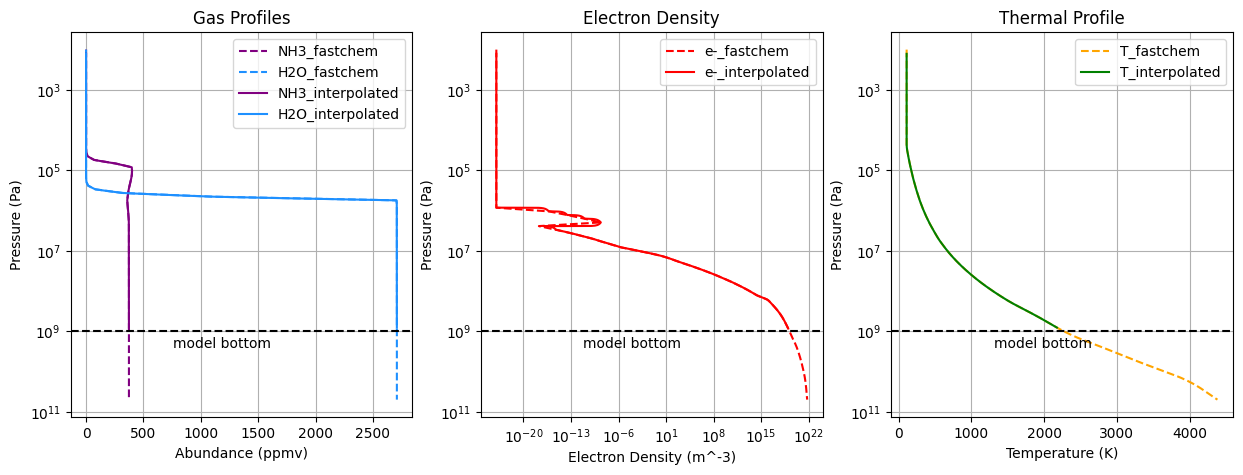

In [8]:

# plot the profiles
import matplotlib.pyplot as plt 
fig,[ax1,ax2,ax3]=plt.subplots(1,3, figsize=(15, 5))

ax1.semilogy(xNH3, pressure, '--', label='NH3_fastchem', color='purple')
ax1.semilogy(xH2O, pressure,'--',  label='H2O_fastchem', color='dodgerblue')
# ax1.semilogy(NH3_org, pressure_model, '--', label='NH3_org', color='purple')
# ax1.semilogy(H2O_org, pressure_model, '--', label='H2O_org', color='dodgerblue')
ax1.semilogy(xNH3_interp, pressure_model, label='NH3_interpolated', color='purple')
ax1.semilogy(xH2O_interp, pressure_model, label='H2O_interpolated', color='dodgerblue')
ax1.set_title('Gas Profiles')
ax1.set_xlabel('Abundance (ppmv)')
ax1.set_ylabel('Pressure (Pa)')
ax1.set_yscale('log')
ax1.invert_yaxis() 
ax1.legend()
ax1.grid()


ax2.semilogy(electron, pressure,  '--',label='e-_fastchem', color='red')
# ax2.semilogy(elec_org, pressure_model, '--', label='e-_org', color='orange')
ax2.plot(electron_interp, pressure_model, label='e-_interpolated', color='red')
ax2.set_title('Electron Density')
ax2.set_xlabel('Electron Density (m^-3)')
ax2.set_ylabel('Pressure (Pa)')
ax2.set_yscale('log')
ax2.set_xscale('log')
ax2.invert_yaxis()
ax2.legend()
ax2.grid()

ax3.plot(temps, pressure,  '--',label='T_fastchem', color='orange')
# ax3.plot(temp_org, pressure_model, '--', label='T_org', color='green')
ax3.plot(temp_interp, pressure_model, label='T_interpolated', color='green')
ax3.set_title('Thermal Profile')
ax3.set_xlabel('Temperature (K)')
ax3.set_ylabel('Pressure (Pa)')
ax3.set_yscale('log')
ax3.invert_yaxis()
ax3.legend()
ax3.grid()

for ax in [ax1, ax2, ax3]:
    ax.axhline(y=1E9, color='black', linestyle='--', label='model bottom')
    ax.text(0.3,0.18, 'model bottom', transform=ax.transAxes)



In [ ]:
# overwrite the layer properties in the meshblock
vector=[temp_interp, electron_interp, xNH3_interp, xH2O_interp, pressure_model] 

for ilayer, rec in enumerate(zip(*vector)):
    temp, elec, nh3_ppmv,h2o_ppmv, pa = rec
    # print(f"Layer {ilayer}: T={temp}, NH3={nh3_ppmv}, H2O={h2o_ppmv}, e-={elec}, P={pa}")

    # ilayer = np.argmin(np.abs(pressure_model - pa))

    # overwrite the layer properties
    overwrite_layer_properties(mb, ilayer, temp, nh3_ppmv, h2o_ppmv, elec)
    # query the layer properties
    query_layer_properties(mb, ilayer)



In [10]:

## ===============================================================================================
##                           calculate the radiance
## -----------------------------------------------------------------------------------------------

# get radance obj
rad = mb.get_rad()
nband = rad.get_num_bands()

# calculate the radiance for the Jindex_st column
rad.cal_radiance(mb, mb.k_st, mb.j_st + Jindex)
nray=len(angle)
tb = np.array([0.0] * nray * nband)

print(f"Number of bands: {nband}, Number of angles: {nray}")

for ib in range(nband):
    toa = rad.get_band(ib).get_toa()[0]
    tb[ib * nray : (ib+1) * nray] = toa


# with h5py.File(f'juno_mwr_fwd_case(metallicity={metallicity})-baseline.h5', 'w') as h5file:
#     h5file.create_dataset('tb', data=tb)



Number of bands: 6, Number of angles: 4


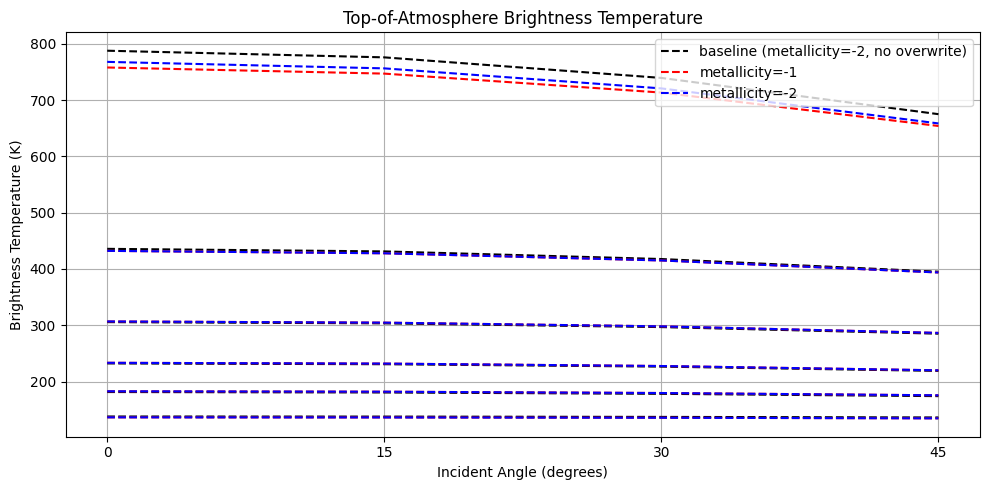

In [11]:
with h5py.File(f'juno_mwr_fwd_case(metallicity=-2)-baseline.h5', 'r') as h5file:
    tb0 = h5file['tb'][:]
with h5py.File(f'juno_mwr_fwd_case(metallicity=-1).h5', 'r') as h5file:
    tb_1 = h5file['tb'][:]
with h5py.File(f'juno_mwr_fwd_case(metallicity=-2).h5', 'r') as h5file:
    tb_2 = h5file['tb'][:]

# plot the radiance of different metallicity
plt.figure(figsize=(10, 5))
for ib in range(nband):
    plt.plot(angle, tb0[ib * nray : (ib+1) * nray], "k--")
    plt.plot(angle, tb_1[ib * nray : (ib+1) * nray], "r--" )
    plt.plot(angle, tb_2[ib * nray : (ib+1) * nray], "b--")
plt.plot([],[], "k--" ,label=f'baseline (metallicity=-2, no overwrite)')
plt.plot([],[], "r--" ,label=f'metallicity=-1')
plt.plot([],[], "b--", label=f'metallicity=-2')
plt.title('Top-of-Atmosphere Brightness Temperature')
plt.xlabel('Incident Angle (degrees)')
plt.ylabel('Brightness Temperature (K)')
plt.xticks(angle)
plt.legend()
plt.tight_layout()
plt.grid()